In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#set visual style
sns.set_theme(style="whitegrid")

In [3]:
# Loading directly from Seaborn's built-in datasets
df=sns.load_dataset("titanic")
print("Dataset loaded successfully")
print(df.head())

Dataset loaded successfully
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [5]:
# Handle missing values
df["age"]=df["age"].fillna(df["age"].median())
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])
df.drop(columns=["deck"],inplace=True,errors="ignore")


In [6]:
# Feature Engineering
df["FamilySize"] = df["sibsp"] + df["parch"]
df["AgeGroup"] = pd.cut(df["age"], bins=[0,12,18,30,50,80], 
                        labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"])

print("Data Cleaning and Feature Engineering Complete.")

Data Cleaning and Feature Engineering Complete.


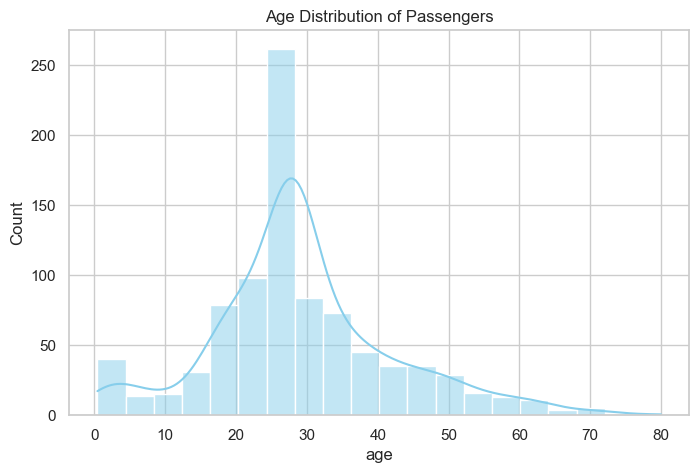

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True, color="skyblue")
plt.title("Age Distribution of Passengers")
plt.savefig('age_distribution.png')
plt.show()

C:\Users\CPS\AppData\Local\Temp\ipykernel_6544\650453614.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sex", y="survived", data=df, palette="muted")


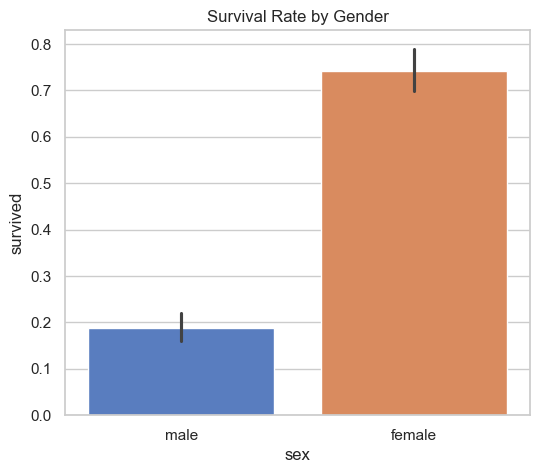

In [10]:
# Insight: Most passengers were young adults between the ages of 20 and 35.

#  Bar Chart - Survival by Sex
plt.figure(figsize=(6, 5))
sns.barplot(x="sex", y="survived", data=df, palette="muted")
plt.title("Survival Rate by Gender")
plt.savefig('survival_by_gender.png')
plt.show()

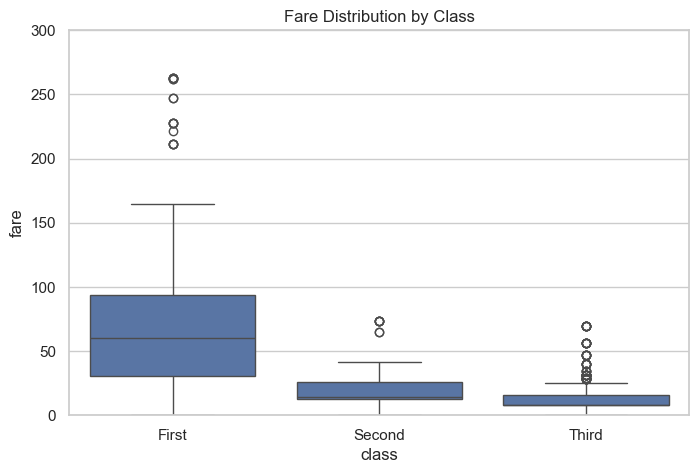

In [11]:

#  Boxplot - Fare by Class
plt.figure(figsize=(8, 5))
sns.boxplot(x="class", y="fare", data=df)
plt.title("Fare Distribution by Class")
plt.ylim(0, 300) # Zooming in for clarity
plt.savefig('fare_by_class.png')
plt.show()

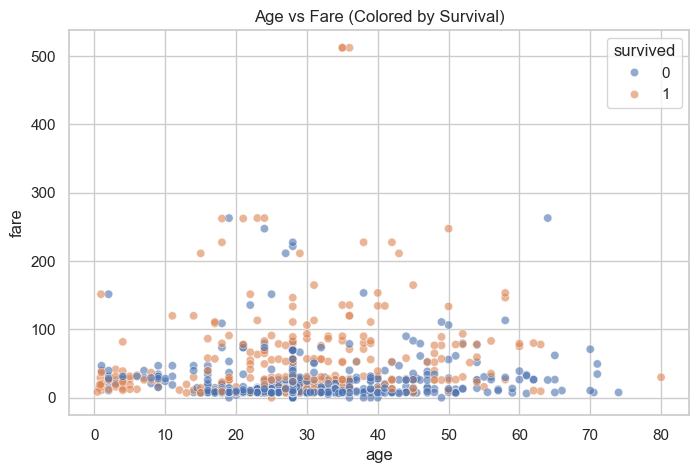

In [12]:
#  Scatterplot - Age vs Fare
plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="fare", hue="survived", data=df, alpha=0.6)
plt.title("Age vs Fare (Colored by Survival)")
plt.savefig('age_vs_fare.png')
plt.show()

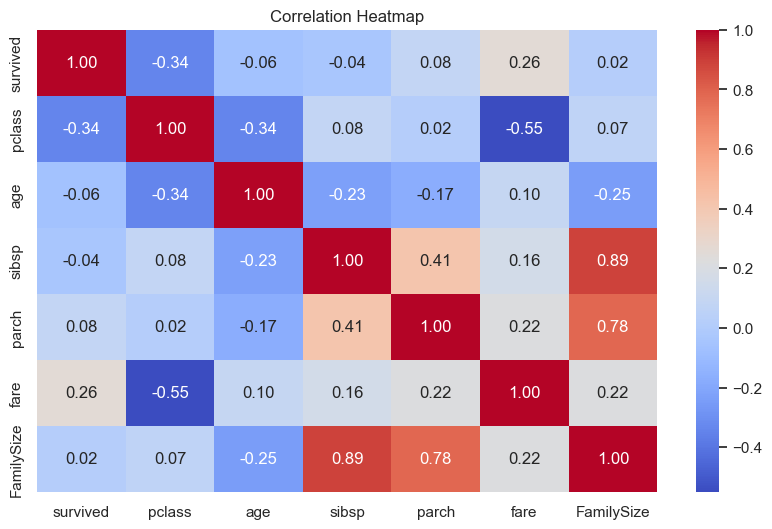

In [14]:
#  Heatmap - Correlation
plt.figure(figsize=(10, 6))
# Selecting only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig('correlation_heatmap.png')
plt.show()
# Insight: There is a strong negative correlation between Class and Fare.